## 기본 Command 사용법 - 간단한 쇼핑몰 주문 처리

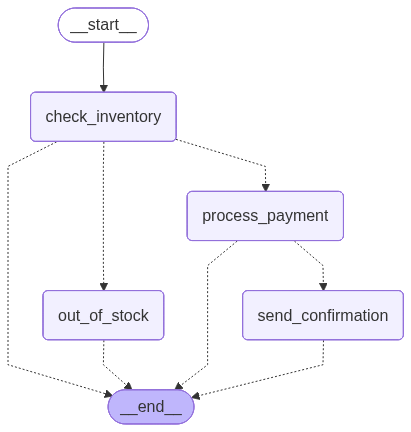

In [3]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import TypedDict

class OrderState(TypedDict):
    customer_name: str
    item: str
    quantity: int
    price: float
    status: str
    messages: list

def check_inventory(state: OrderState) -> Command[Literal["process_payment", "out_of_stock", END]]:
    """재고 확인 후 다음 단계 결정"""
    item = state["item"]
    quantity = state["quantity"]

    # 간단한 재고 확인 (실제로는 DB 조회)
    available_stock = {"사과": 10, "바나나": 5, "오렌지": 0}
    stock = available_stock.get(item, 0)

    if stock >= quantity:
        # 재고 충분 - 결제 처리로 이동
        return Command(
            goto="process_payment",
            update={
                "status": "재고 확인 완료",
                "messages": state["messages"] + [f"{item} {quantity}개 재고 확인됨"]
            }
        )
    else:
        # 재고 부족 - 품절 처리로 이동
        return Command(
            goto="out_of_stock",
            update={
                "status": "재고 부족",
                "messages": state["messages"] + [f"{item} 재고 부족 (요청: {quantity}개, 보유: {stock}개)"]
            }
        )

def process_payment(state: OrderState) -> Command[Literal["send_confirmation", END]]:
    """결제 처리"""
    total_price = state["quantity"] * state["price"]

    return Command(
        goto="send_confirmation",
        update={
            "status": "결제 완료",
            "messages": state["messages"] + [f"결제 완료: {total_price}원"]
        }
    )

def out_of_stock(state: OrderState) -> Command[Literal[END]]:
    """품절 처리"""
    return Command(
        goto=END,
        update={
            "status": "주문 취소됨",
            "messages": state["messages"] + ["죄송합니다. 품절로 인해 주문이 취소되었습니다."]
        }
    )

def send_confirmation(state: OrderState) -> Command[Literal[END]]:
    """주문 확인 메시지 발송"""
    customer = state["customer_name"]

    return Command(
        goto=END,
        update={
            "status": "주문 완료",
            "messages": state["messages"] + [f"{customer}님께 주문 확인 메시지를 발송했습니다."]
        }
    )

# 쇼핑몰 주문 처리 그래프
order_graph = StateGraph(OrderState)
order_graph.add_node("check_inventory", check_inventory)
order_graph.add_node("process_payment", process_payment)
order_graph.add_node("out_of_stock", out_of_stock)
order_graph.add_node("send_confirmation", send_confirmation)

order_graph.add_edge(START, "check_inventory")
order_app = order_graph.compile()

from IPython.display import Image, display
display(Image(order_app.get_graph().draw_mermaid_png()))


In [5]:
# 쇼핑몰 주문 처리 예제
print("=== 쇼핑몰 주문 처리 ===")

# 성공 케이스
success_result = order_app.invoke({
    "customer_name": "김철수",
    "item": "사과",
    "quantity": 3,
    "price": 1000,
    "status": "",
    "messages": []
})

print(f"고객: {success_result['customer_name']}")
print(f"최종 상태: {success_result['status']}")
print("처리 과정:")
for msg in success_result['messages']:
    print(f"  - {msg}")

print("\n" + "="*50 + "\n")

# 실패 케이스 (품절)
fail_result = order_app.invoke({
    "customer_name": "이영희",
    "item": "오렌지",
    "quantity": 2,
    "price": 1500,
    "status": "",
    "messages": []
})

print(f"고객: {fail_result['customer_name']}")
print(f"최종 상태: {fail_result['status']}")
print("처리 과정:")
for msg in fail_result['messages']:
    print(f"  - {msg}")


=== 쇼핑몰 주문 처리 ===
고객: 김철수
최종 상태: 주문 완료
처리 과정:
  - 사과 3개 재고 확인됨
  - 결제 완료: 3000원
  - 김철수님께 주문 확인 메시지를 발송했습니다.


고객: 이영희
최종 상태: 주문 취소됨
처리 과정:
  - 오렌지 재고 부족 (요청: 2개, 보유: 0개)
  - 죄송합니다. 품절로 인해 주문이 취소되었습니다.
